# Complete EDA — Crypto Hourly OHLCV (BTC, ETH, BNB, SOL)

**This notebook is the only EDA for the project.** Run it start to finish (Runtime → Run all). Do not look for EDA in `src/`. Feature engineering comes *after* you send this executed notebook back.

### Colab
1. Upload `data/raw.csv` into `/content/` (or next to the notebook).
2. Runtime → Run all.
3. Download this executed `.ipynb` and `eda_findings.json`.

No model training in this file.


In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q pandas numpy matplotlib seaborn pyarrow requests

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

try:
    from IPython.display import display
except ImportError:
    display = print

print("IN_COLAB =", IN_COLAB)


IN_COLAB = True


## 0. What this data is

| Question | Answer |
|---|---|
| Purpose | Hourly Binance OHLCV so we can forecast **next-24h realized volatility** (regression), not price direction. |
| Source | Public Binance `/api/v3/klines` (no API key). Not personal data. |
| Update cadence | New candle every hour; pipeline can refresh every 6 hours. |
| Target (defined later) | `vol_24h = std(log_return[t+1], ..., log_return[t+24])` |


## 1. Load raw data


In [2]:
CANDIDATES = [
    Path("data/raw.csv"),
    Path("data/raw.parquet"),
    Path("/content/raw.csv"),
    Path("/content/data/raw.csv"),
]

def load_raw():
    for path in CANDIDATES:
        if path.exists():
            print("Loaded", path.resolve() if path.exists() else path)
            if path.suffix == ".parquet":
                return pd.read_parquet(path), str(path)
            return pd.read_csv(path), str(path)

    if IN_COLAB:
        from google.colab import files
        print("No file found. Upload data/raw.csv")
        uploaded = files.upload()
        name = next(iter(uploaded))
        return pd.read_csv(name), name

    import requests
    from datetime import datetime, timedelta, timezone
    print("No local file. Fetching 90 days from Binance (fallback)...")
    symbols = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT"]
    end = datetime.now(timezone.utc)
    start = end - timedelta(days=90)
    frames = []
    for symbol in symbols:
        cursor = int(start.timestamp() * 1000)
        end_ms = int(end.timestamp() * 1000)
        rows = []
        while cursor < end_ms:
            r = requests.get(
                "https://api.binance.com/api/v3/klines",
                params={"symbol": symbol, "interval": "1h", "startTime": cursor, "endTime": end_ms, "limit": 1000},
                timeout=30,
            )
            r.raise_for_status()
            batch = r.json()
            if not batch:
                break
            rows.extend(batch)
            cursor = int(batch[-1][0]) + 1
            if len(batch) < 1000:
                break
        part = pd.DataFrame(
            rows,
            columns=[
                "open_time", "open", "high", "low", "close", "volume", "close_time",
                "quote_volume", "trades", "taker_buy_base", "taker_buy_quote", "ignore",
            ],
        ).drop(columns=["ignore"])
        part["symbol"] = symbol
        frames.append(part)
    return pd.concat(frames, ignore_index=True), "binance_api_fallback"

raw, SOURCE = load_raw()
df = raw.copy()
print("source =", SOURCE)
print("shape =", df.shape)
display(df.head())


Loaded /content/raw.csv
source = /content/raw.csv
shape = (51840, 12)


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote,symbol
0,2025-02-24 15:00:00+00:00,634.11,639.00,630.10,635.24,35262.543,2025-02-24 15:59:59.999000+00:00,2.236360e+07,123562,16376.259,1.039545e+07,BNBUSDT
1,2025-02-24 16:00:00+00:00,635.25,638.41,633.72,635.99,9182.194,2025-02-24 16:59:59.999000+00:00,5.846949e+06,50830,5028.381,3.202443e+06,BNBUSDT
2,2025-02-24 17:00:00+00:00,635.99,639.75,635.68,636.43,11050.886,2025-02-24 17:59:59.999000+00:00,7.050415e+06,48255,5605.479,3.576368e+06,BNBUSDT
3,2025-02-24 18:00:00+00:00,636.44,637.44,633.01,633.03,5555.750,2025-02-24 18:59:59.999000+00:00,3.529837e+06,34827,2874.486,1.826806e+06,BNBUSDT
4,2025-02-24 19:00:00+00:00,633.02,634.50,622.00,628.46,20930.485,2025-02-24 19:59:59.999000+00:00,1.313640e+07,81030,7104.836,4.464324e+06,BNBUSDT


## 2. Dataset structure (7 questions)

1. How big is the data?  
2. How does it look (`head` / `sample`)?  
3. What is the dtype of each column?  
4. Missing values?  
5. Mathematical summary (`describe`)?  
6. Duplicates?  
7. Correlation between columns? (full heatmap in bivariate section)


In [3]:
print("Q1  shape:", df.shape, "  cells:", df.size)
print("Q2  columns:", list(df.columns))
display(df.head(3))
display(df.tail(3))
display(df.sample(5, random_state=42))
print("Q3  info:")
df.info()
print("\nQ4  missing / null per column:")
display(pd.DataFrame({"nulls": df.isnull().sum(), "pct": (df.isnull().mean() * 100).round(4)}))
print("Q5  describe (numeric):")
display(df.describe())
print("Q5b describe (all):")
display(df.describe(include="all"))
print("Q6  duplicated rows:", int(df.duplicated().sum()))


Q1  shape: (51840, 12)   cells: 622080
Q2  columns: ['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_volume', 'trades', 'taker_buy_base', 'taker_buy_quote', 'symbol']


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote,symbol
0,2025-02-24 15:00:00+00:00,634.11,639.00,630.10,635.24,35262.543,2025-02-24 15:59:59.999000+00:00,2.236360e+07,123562,16376.259,1.039545e+07,BNBUSDT
1,2025-02-24 16:00:00+00:00,635.25,638.41,633.72,635.99,9182.194,2025-02-24 16:59:59.999000+00:00,5.846949e+06,50830,5028.381,3.202443e+06,BNBUSDT
2,2025-02-24 17:00:00+00:00,635.99,639.75,635.68,636.43,11050.886,2025-02-24 17:59:59.999000+00:00,7.050415e+06,48255,5605.479,3.576368e+06,BNBUSDT


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote,symbol
51837,2026-08-18 12:00:00+00:00,76.32,76.52,76.23,76.25,59789.622,2026-08-18 12:59:59.999000+00:00,4.567651e+06,13039,29141.620,2.226228e+06,SOLUSDT
51838,2026-08-18 13:00:00+00:00,76.25,76.30,76.05,76.21,49236.302,2026-08-18 13:59:59.999000+00:00,3.748851e+06,14619,20280.668,1.544263e+06,SOLUSDT
51839,2026-08-18 14:00:00+00:00,76.21,77.08,76.12,77.01,76096.955,2026-08-18 14:59:59.999000+00:00,5.832939e+06,20697,44045.143,3.377713e+06,SOLUSDT


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote,symbol
19620,2025-11-29 03:00:00+00:00,90798.90,90874.03,90661.12,90680.26,203.76865,2025-11-29 03:59:59.999000+00:00,1.849687e+07,57847,112.29726,1.019513e+07,BTCUSDT
26679,2025-03-28 06:00:00+00:00,1915.62,1928.48,1911.88,1915.48,26216.92010,2025-03-28 06:59:59.999000+00:00,5.033366e+07,96374,15167.20660,2.911807e+07,ETHUSDT
38293,2026-07-25 04:00:00+00:00,1858.74,1862.65,1858.57,1861.28,1922.53290,2026-07-25 04:59:59.999000+00:00,3.577359e+06,24259,1115.28030,2.075297e+06,ETHUSDT
25638,2026-08-06 21:00:00+00:00,64439.71,64513.99,64404.74,64440.74,249.73283,2026-08-06 21:59:59.999000+00:00,1.609794e+07,53362,122.75076,7.912460e+06,BTCUSDT
29563,2025-07-26 10:00:00+00:00,3759.11,3782.83,3752.56,3759.93,24687.22510,2025-07-26 10:59:59.999000+00:00,9.301693e+07,94514,13349.89920,5.031381e+07,ETHUSDT


Q3  info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51840 entries, 0 to 51839
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   open_time        51840 non-null  object 
 1   open             51840 non-null  float64
 2   high             51840 non-null  float64
 3   low              51840 non-null  float64
 4   close            51840 non-null  float64
 5   volume           51840 non-null  float64
 6   close_time       51840 non-null  object 
 7   quote_volume     51840 non-null  float64
 8   trades           51840 non-null  int64  
 9   taker_buy_base   51840 non-null  float64
 10  taker_buy_quote  51840 non-null  float64
 11  symbol           51840 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 4.7+ MB

Q4  missing / null per column:


...

Q5  describe (numeric):


,open,high,low,close,volume,quote_volume,trades,taker_buy_base,taker_buy_quote
count,51840.000000,51840.000000,51840.000000,51840.000000,5.184000e+04,5.184000e+04,5.184000e+04,5.184000e+04,5.184000e+04
mean,23213.845013,23283.855480,23140.903826,23213.255742,4.299615e+04,3.866007e+07,1.079347e+05,2.135135e+04,1.898758e+07
std,39304.751672,39416.242221,39188.430640,39303.936170,9.366784e+04,5.958126e+07,1.197307e+05,4.695626e+04,2.943249e+07
min,60.890000,61.940000,60.130000,60.880000,4.643346e+01,3.192216e+05,2.574000e+03,1.804477e+01,1.591333e+05
25%,451.600000,461.927500,442.707500,451.607500,1.931241e+03,6.868400e+06,3.480375e+04,9.347458e+02,3.369463e+06
50%,1393.775000,1400.870000,1364.275000,1393.780000,8.945567e+03,1.974930e+07,7.022200e+04,4.375746e+03,9.548723e+06
75%,18274.182500,18372.247500,18123.030000,18273.792500,4.416499e+04,4.680922e+07,1.342310e+05,2.159329e+04,2.276213e+07
max,126011.180000,126199.630000,125252.740000,126011.180000,4.005169e+06,2.527603e+09,3.520247e+06,2.199906e+06,1.199587e+09


Q5b describe (all):


,open_time,open,high,low,close,volume,close_time,quote_volume,trades,taker_buy_base,taker_buy_quote,symbol
count,51840,51840.000000,51840.000000,51840.000000,51840.000000,5.184000e+04,51840,5.184000e+04,5.184000e+04,5.184000e+04,5.184000e+04,51840
unique,12960,NaN,NaN,NaN,NaN,NaN,12960,NaN,NaN,NaN,NaN,4
top,2026-08-16 23:00:00+00:00,NaN,NaN,NaN,NaN,NaN,2026-08-16 23:59:59.999000+00:00,NaN,NaN,NaN,NaN,BNBUSDT
freq,4,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,12960
mean,NaN,23213.845013,23283.855480,23140.903826,23213.255742,4.299615e+04,NaN,3.866007e+07,1.079347e+05,2.135135e+04,1.898758e+07,NaN
std,NaN,39304.751672,39416.242221,39188.430640,39303.936170,9.366784e+04,NaN,5.958126e+07,1.197307e+05,4.695626e+04,2.943249e+07,NaN
min,NaN,60.890000,61.940000,60.130000,60.880000,4.643346e+01,NaN,3.192216e+05,2.574000e+03,1.804477e+01,1.591333e+05,NaN
25%,NaN,451.600000,461.927500,442.707500,451.607500,1.931241e+03,NaN,6.868400e+06,3.480375e+04,9.347458e+02,3.369463e+06,NaN
50%,NaN,1393.775000,1400.870000,1364.275000,1393.780000,8.945567e+03,NaN,1.974930e+07,7.022200e+04,4.375746e+03,9.548723e+06,NaN
75%,NaN,18274.182500,18372.247500,18123.030000,18273.792500,4.416499e+04,NaN,4.680922e+07,1.342310e+05,2.159329e+04,2.276213e+07,NaN


Q6  duplicated rows: 0


## 3. Types, datetime format, and identity columns


In [4]:
df["open_time"] = pd.to_datetime(df["open_time"], utc=True, errors="coerce")
df["close_time"] = pd.to_datetime(df["close_time"], utc=True, errors="coerce")
NUM = ["open", "high", "low", "close", "volume", "quote_volume", "trades", "taker_buy_base", "taker_buy_quote"]
for c in NUM:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.sort_values(["symbol", "open_time"]).reset_index(drop=True)
print("open_time dtype:", df["open_time"].dtype)
print("close_time dtype:", df["close_time"].dtype)
print("datetime parse failures (open_time):", int(df["open_time"].isna().sum()))
print("range:", df["open_time"].min(), "→", df["open_time"].max())
print("span_days:", (df["open_time"].max() - df["open_time"].min()).days)
print("symbols:", sorted(df["symbol"].dropna().unique().tolist()))
print("rows per symbol:")
display(df["symbol"].value_counts().sort_index().to_frame("n"))
print("hour-of-day coverage (should be 0-23):")
print(sorted(df["open_time"].dt.hour.dropna().unique().tolist()))


open_time dtype: datetime64[ns, UTC]
close_time dtype: datetime64[ns, UTC]
datetime parse failures (open_time): 0
range: 2025-02-24 15:00:00+00:00 → 2026-08-18 14:00:00+00:00
span_days: 539
symbols: ['BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT']
rows per symbol:


,n
symbol,
BNBUSDT,12960
BTCUSDT,12960
ETHUSDT,12960
SOLUSDT,12960


hour-of-day coverage (should be 0-23):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


## 4. Data quality and inconsistencies

Missing values, duplicates, OHLC rules, non-positive prices, volume, and **missing hourly bars**.


In [5]:
issues = {
    "null_cells": int(df.isna().sum().sum()),
    "dup_full_row": int(df.duplicated().sum()),
    "dup_symbol_open_time": int(df.duplicated(["symbol", "open_time"]).sum()),
    "high_lt_low": int((df["high"] < df["low"]).sum()),
    "high_below_open_or_close": int((df["high"] < df[["open", "close"]].max(axis=1)).sum()),
    "low_above_open_or_close": int((df["low"] > df[["open", "close"]].min(axis=1)).sum()),
    "nonpositive_ohlc": int(((df[["open", "high", "low", "close"]] <= 0).any(axis=1)).sum()),
    "negative_volume": int((df["volume"] < 0).sum()),
    "zero_volume": int((df["volume"] == 0).sum()),
    "trades_negative": int((df["trades"] < 0).sum()) if "trades" in df.columns else 0,
}

gap_rows = []
missing_examples = {}
for symbol, g in df.groupby("symbol"):
    g = g.drop_duplicates(["open_time"]).sort_values("open_time")
    expected = pd.date_range(g["open_time"].min(), g["open_time"].max(), freq="h", tz="UTC")
    missing = expected.difference(pd.DatetimeIndex(g["open_time"]))
    deltas = g["open_time"].diff().dropna()
    gap_rows.append({
        "symbol": symbol,
        "n_rows": int(len(g)),
        "missing_hours": int(len(missing)),
        "max_gap_hours": float(deltas.max() / pd.Timedelta(hours=1)) if len(deltas) else np.nan,
        "min_gap_hours": float(deltas.min() / pd.Timedelta(hours=1)) if len(deltas) else np.nan,
    })
    missing_examples[symbol] = [str(x) for x in list(missing[:8])]

gap_tbl = pd.DataFrame(gap_rows)
print("Quality flag counts (0 = clean):")
display(pd.Series(issues, name="count"))
print("Hourly calendar coverage:")
display(gap_tbl)
print("First missing hours (if any):")
display(missing_examples)


Quality flag counts (0 = clean):


,count
null_cells,0
dup_full_row,0
dup_symbol_open_time,0
high_lt_low,0
high_below_open_or_close,0
low_above_open_or_close,0
nonpositive_ohlc,0
negative_volume,0
zero_volume,0
trades_negative,0


Hourly calendar coverage:


,symbol,n_rows,missing_hours,max_gap_hours,min_gap_hours
0,BNBUSDT,12960,0,1.0,1.0
1,BTCUSDT,12960,0,1.0,1.0
2,ETHUSDT,12960,0,1.0,1.0
3,SOLUSDT,12960,0,1.0,1.0


First missing hours (if any):


{'BNBUSDT': [], 'BTCUSDT': [], 'ETHUSDT': [], 'SOLUSDT': []}

## 5. Derived fields used only for EDA (not the production feature store)


In [6]:
df["log_return"] = df.groupby("symbol")["close"].transform(lambda s: np.log(s / s.shift(1)))
df["abs_return"] = df["log_return"].abs()
df["candle_range"] = (df["high"] - df["low"]) / df["close"].replace(0, np.nan)
df["hour"] = df["open_time"].dt.hour
df["dow"] = df["open_time"].dt.dayofweek  # Monday=0
df["vol_24h_hist"] = df.groupby("symbol")["log_return"].transform(lambda s: s.rolling(24).std())

# Target at t: std of the NEXT 24 returns
HORIZON = 24
parts = []
for symbol, g in df.groupby("symbol"):
    g = g.copy()
    g["vol_24h"] = g["log_return"].rolling(HORIZON).std().shift(-HORIZON)
    parts.append(g)
df = pd.concat(parts, ignore_index=True).sort_values(["symbol", "open_time"]).reset_index(drop=True)
print("log_return / vol_24h ready. Target NaNs (warmup + last 24 bars):", int(df["vol_24h"].isna().sum()))


log_return / vol_24h ready. Target NaNs (warmup + last 24 bars): 96


## 6. Univariate analysis


In [7]:
uni_cols = ["close", "volume", "trades", "log_return", "candle_range", "vol_24h_hist", "vol_24h"]
print("Per-symbol univariate stats:")
for col in uni_cols:
    print(f"\n=== {col} ===")
    display(df.groupby("symbol")[col].describe())


Per-symbol univariate stats:

=== close ===


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BNBUSDT,12960.0,732.460576,165.251844,518.35,607.2225,652.34,859.000,1368.76
BTCUSDT,12960.0,89313.559549,18684.021107,58290.17,71313.0600,87902.55,107438.425,126011.18
ETHUSDT,12960.0,2675.592145,883.062877,1418.80,1952.2725,2381.86,3171.735,4935.00
SOLUSDT,12960.0,131.410697,46.158880,60.88,85.1875,132.49,163.275,251.38



=== volume ===


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BNBUSDT,12960.0,9641.359869,14244.277514,497.56400,3465.914250,5793.20400,10654.676500,5.135712e+05
BTCUSDT,12960.0,815.326569,898.388980,46.43346,344.558963,559.75944,952.755275,2.293263e+04
ETHUSDT,12960.0,20098.749671,22899.245967,847.55230,7634.991100,13248.93725,24138.179425,4.202890e+05
SOLUSDT,12960.0,141429.182260,145816.595314,9201.99000,63381.537750,101296.06200,167985.781750,4.005169e+06



=== trades ===


...

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BNBUSDT,12960.0,0.007023,0.006093,0.000510,0.003614,0.005445,0.008580,0.309898
BTCUSDT,12960.0,0.006183,0.004980,0.000228,0.003136,0.004807,0.007579,0.115579
ETHUSDT,12960.0,0.009654,0.007697,0.000489,0.005020,0.007657,0.011758,0.239241
SOLUSDT,12960.0,0.011036,0.008016,0.000794,0.006149,0.008952,0.013520,0.156972



=== vol_24h_hist ===


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BNBUSDT,12936.0,0.004582,0.002507,0.000852,0.002793,0.004036,0.005704,0.024348
BTCUSDT,12936.0,0.004115,0.002172,0.000540,0.002638,0.003694,0.004975,0.017119
ETHUSDT,12936.0,0.006269,0.003114,0.000705,0.004159,0.005719,0.007744,0.023637
SOLUSDT,12936.0,0.007129,0.003400,0.001361,0.004907,0.006519,0.008524,0.036169



=== vol_24h ===


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BNBUSDT,12936.0,0.004582,0.002507,0.000852,0.002793,0.004036,0.005704,0.024348
BTCUSDT,12936.0,0.004115,0.002172,0.000540,0.002638,0.003694,0.004975,0.017119
ETHUSDT,12936.0,0.006269,0.003114,0.000705,0.004159,0.005719,0.007744,0.023637
SOLUSDT,12936.0,0.007129,0.003400,0.001361,0.004907,0.006519,0.008524,0.036169


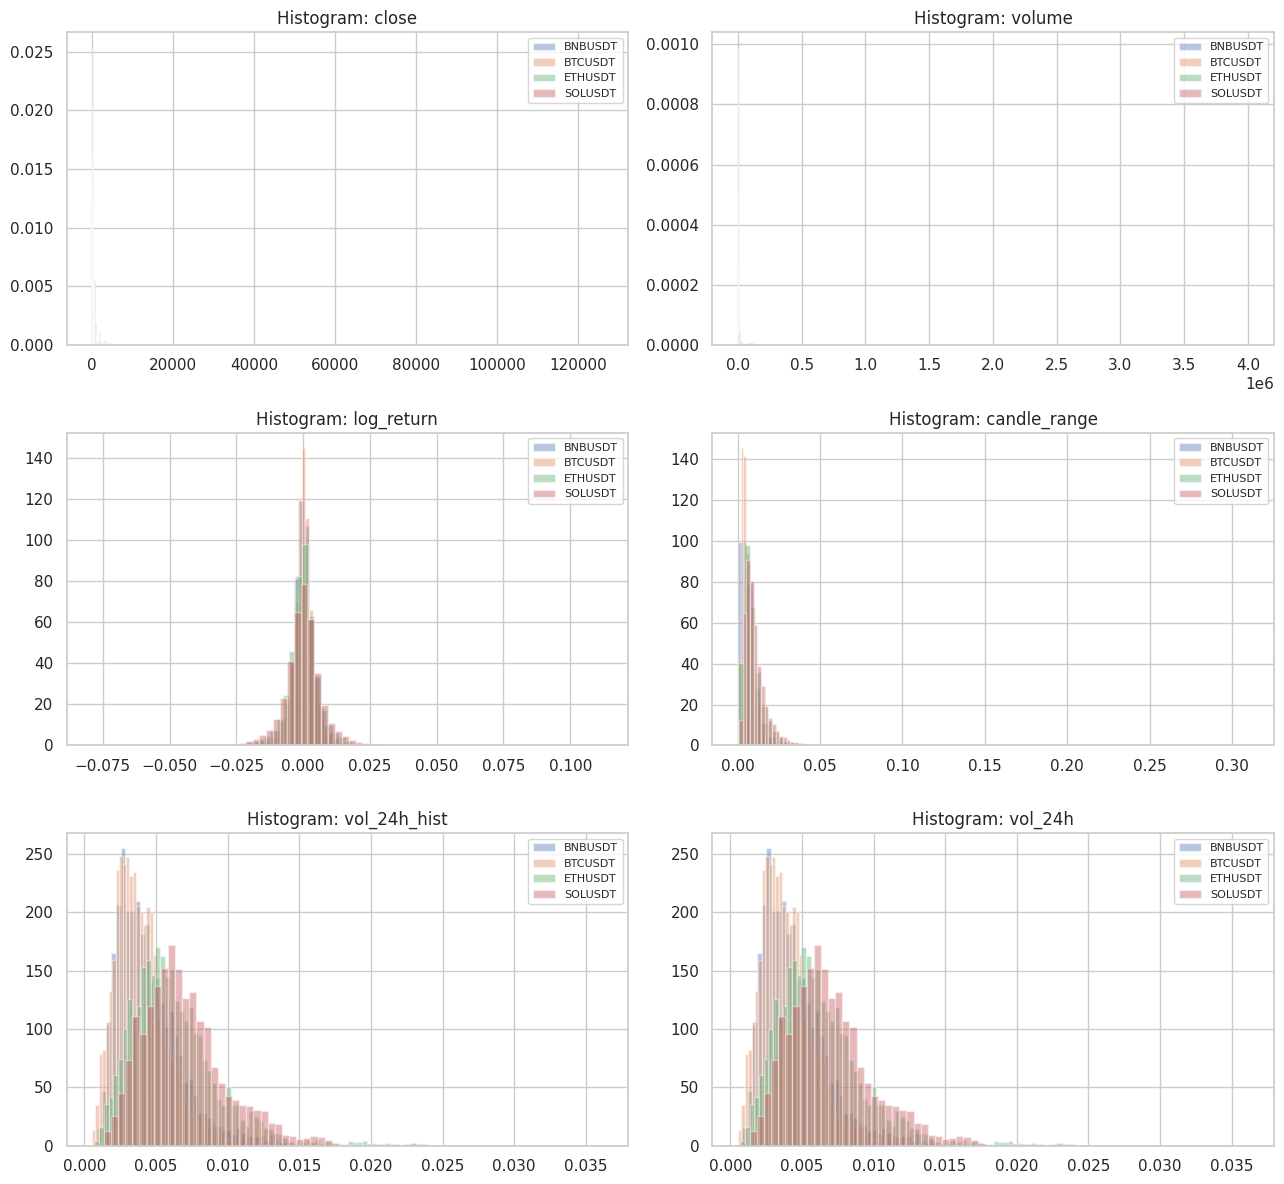

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
plot_cols = ["close", "volume", "log_return", "candle_range", "vol_24h_hist", "vol_24h"]
for ax, col in zip(axes.ravel(), plot_cols):
    for symbol, g in df.groupby("symbol"):
        ax.hist(g[col].dropna(), bins=70, alpha=0.4, density=True, label=symbol)
    ax.set_title(f"Histogram: {col}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


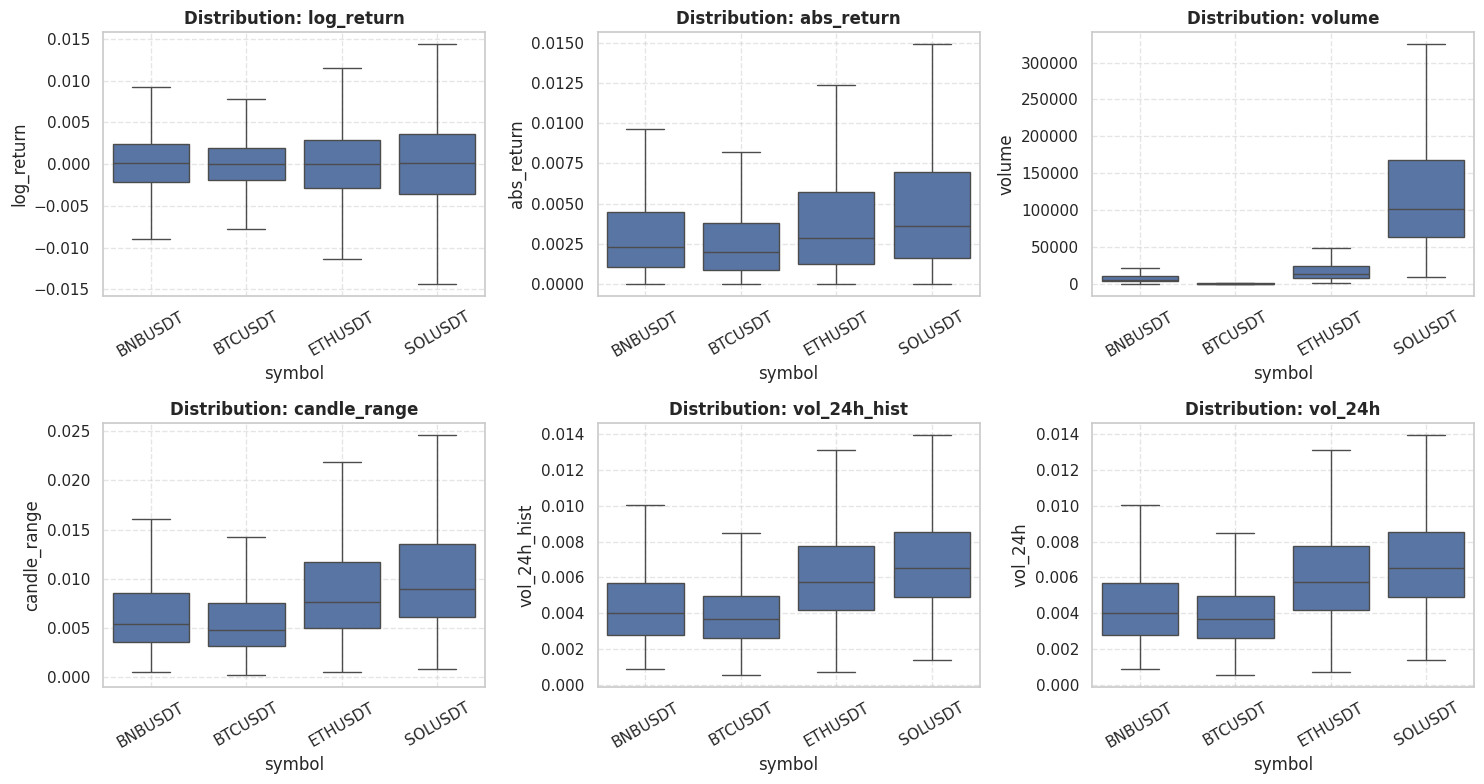

Log Return Distribution Summary:


,mean,std,skew,excess_kurtosis,p05,p95
symbol,,,,,,
BNBUSDT,-0.0000,0.0052,-0.6563,11.9685,-0.0078,0.0076
BTCUSDT,-0.0000,0.0046,-0.3297,11.1714,-0.0069,0.0067
ETHUSDT,-0.0000,0.0070,-0.1230,12.8073,-0.0102,0.0102
SOLUSDT,-0.0001,0.0079,0.1109,11.9086,-0.0121,0.0117


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

cols = ["log_return", "abs_return", "volume", "candle_range", "vol_24h_hist", "vol_24h"]

# 1. Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), cols):
    sns.boxplot(data=df, x="symbol", y=col, ax=ax, showfliers=False)
    ax.set_title(f"Distribution: {col}", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Consolidated Statistical Table
stats_summary = (
    df.groupby("symbol")["log_return"]
    .agg(
        mean="mean",
        std="std",
        skew="skew",
        excess_kurtosis=pd.Series.kurtosis,
        p05=lambda x: x.quantile(0.05),
        p95=lambda x: x.quantile(0.95),
    )
    .round(4)
)

print("Log Return Distribution Summary:")
display(stats_summary)

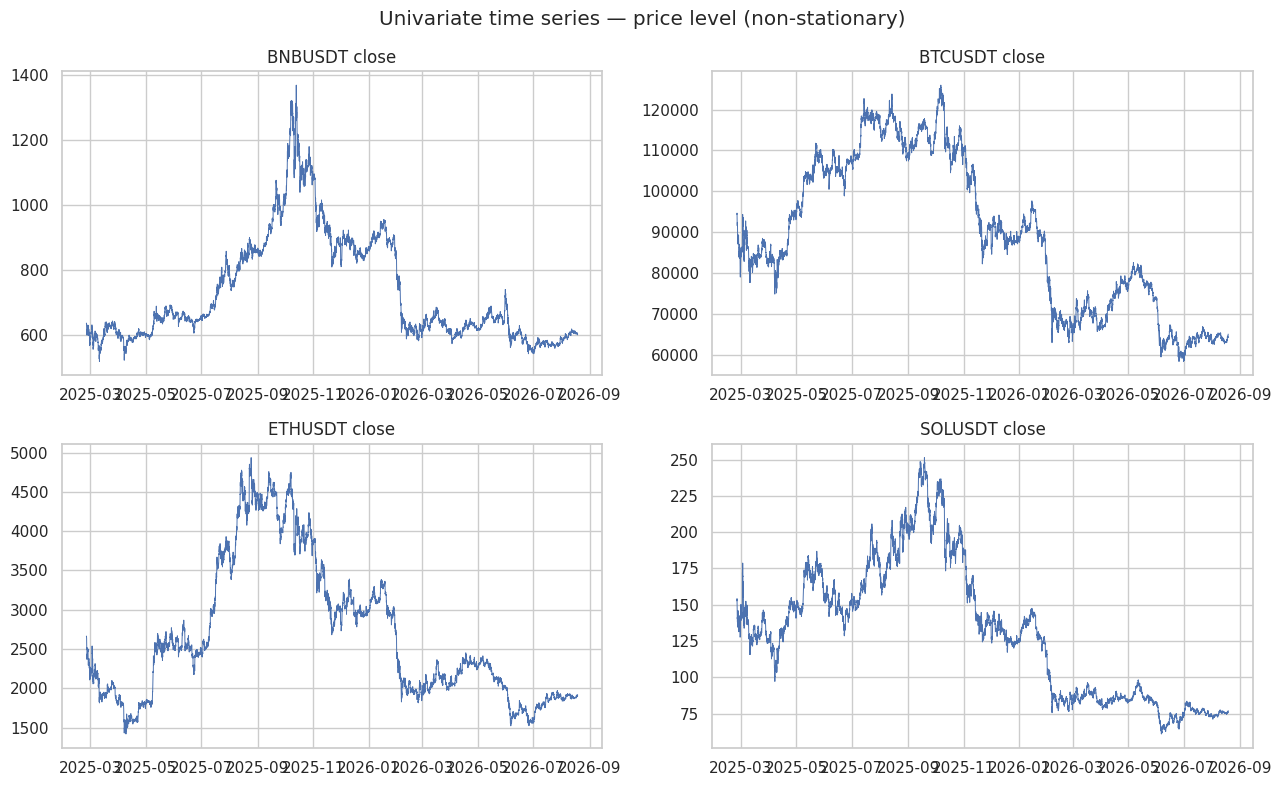

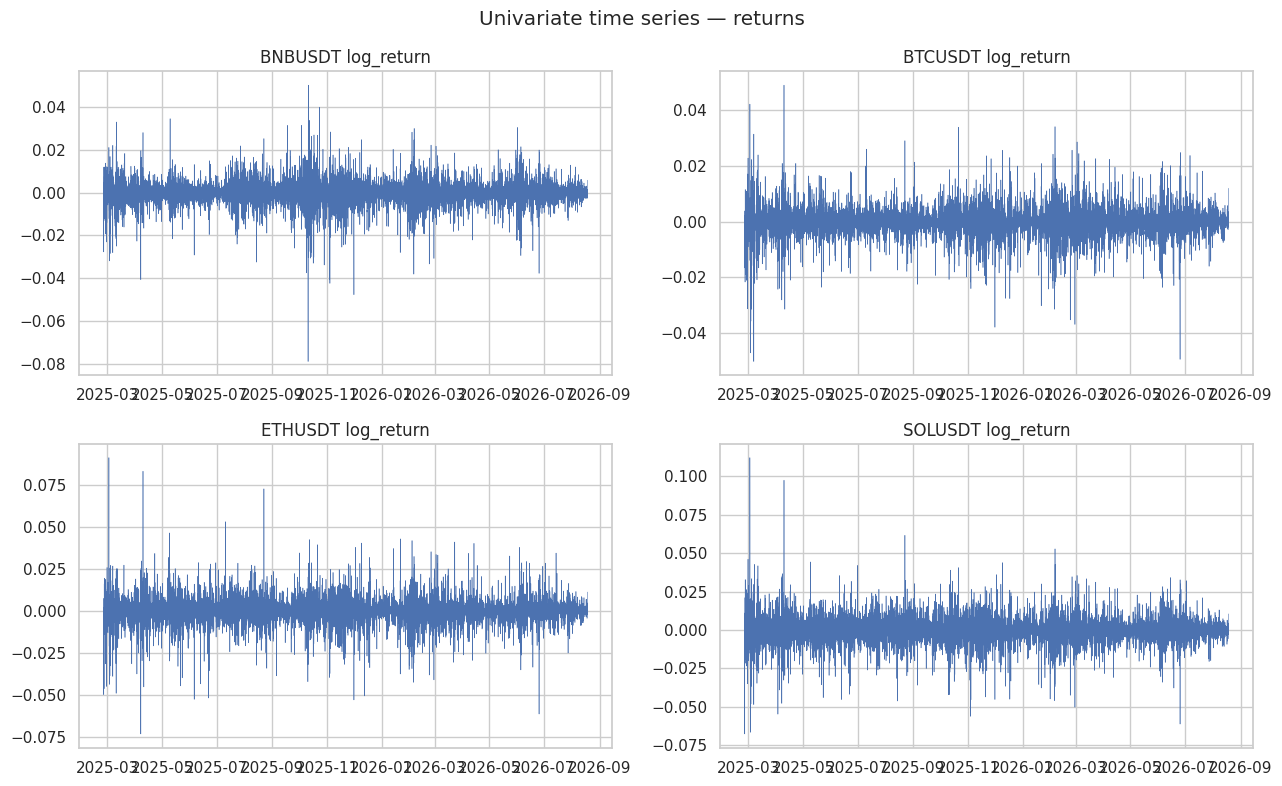

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (symbol, g) in zip(axes.ravel(), df.groupby("symbol")):
    ax.plot(g["open_time"], g["close"], lw=0.7)
    ax.set_title(f"{symbol} close")
plt.suptitle("Univariate time series — price level (non-stationary)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (symbol, g) in zip(axes.ravel(), df.groupby("symbol")):
    ax.plot(g["open_time"], g["log_return"], lw=0.4)
    ax.set_title(f"{symbol} log_return")
plt.suptitle("Univariate time series — returns")
plt.tight_layout()
plt.show()


## 7. Outliers (IQR) — univariate extremes, not deleted here


In [13]:
def iqr_outlier_share(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or s.dropna().empty:
        return 0.0
    return float(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean())

outlier_tbl = []
for col in ["log_return", "volume", "candle_range", "vol_24h"]:
    for symbol, g in df.groupby("symbol"):
        outlier_tbl.append({"col": col, "symbol": symbol, "iqr_outlier_share": iqr_outlier_share(g[col])})
outlier_df = pd.DataFrame(outlier_tbl)
print("Share of IQR outliers (kept; fat tails are expected in crypto):")
display(outlier_df.pivot(index="symbol", columns="col", values="iqr_outlier_share"))


Share of IQR outliers (kept; fat tails are expected in crypto):


col,candle_range,log_return,vol_24h,volume
symbol,,,,
BNBUSDT,0.057407,0.071682,0.039275,0.084645
BTCUSDT,0.058796,0.072454,0.043441,0.075926
ETHUSDT,0.059414,0.078935,0.030324,0.075463
SOLUSDT,0.053395,0.065123,0.035648,0.070988


## 8. Bivariate analysis


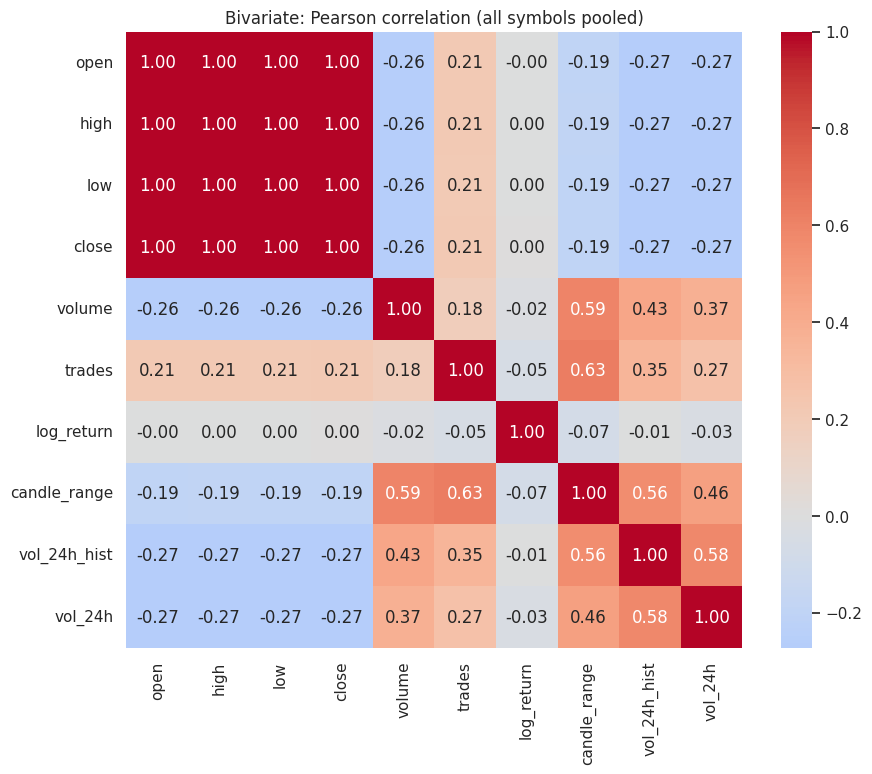

,open,high,low,close,volume,trades,log_return,candle_range,vol_24h_hist,vol_24h
open,1.000000,0.999992,0.999990,0.999987,-0.260606,0.211514,-0.000763,-0.192960,-0.271683,-0.270557
high,0.999992,1.000000,0.999985,0.999993,-0.260616,0.212761,0.000258,-0.192076,-0.271200,-0.270210
low,0.999990,0.999985,1.000000,0.999992,-0.260603,0.209814,0.000380,-0.194110,-0.272190,-0.270989
close,0.999987,0.999993,0.999992,1.000000,-0.260608,0.211304,0.001243,-0.193084,-0.271691,-0.270626
volume,-0.260606,-0.260616,-0.260603,-0.260608,1.000000,0.178945,-0.015557,0.592599,0.432298,0.374980
trades,0.211514,0.212761,0.209814,0.211304,0.178945,1.000000,-0.045352,0.629563,0.349288,0.272907
log_return,-0.000763,0.000258,0.000380,0.001243,-0.015557,-0.045352,1.000000,-0.068855,-0.006385,-0.033816
candle_range,-0.192960,-0.192076,-0.194110,-0.193084,0.592599,0.629563,-0.068855,1.000000,0.561035,0.462047
vol_24h_hist,-0.271683,-0.271200,-0.272190,-0.271691,0.432298,0.349288,-0.006385,0.561035,1.000000,0.580450
vol_24h,-0.270557,-0.270210,-0.270989,-0.270626,0.374980,0.272907,-0.033816,0.462047,0.580450,1.000000


Correlation with target vol_24h:


,corr_with_target
vol_24h,1.000000
vol_24h_hist,0.580450
candle_range,0.462047
volume,0.374980
trades,0.272907
low,-0.270989
close,-0.270626
open,-0.270557
high,-0.270210
log_return,-0.033816


In [14]:
biv_cols = ["open", "high", "low", "close", "volume", "trades", "log_return", "candle_range", "vol_24h_hist", "vol_24h"]
corr = df[biv_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Bivariate: Pearson correlation (all symbols pooled)")
plt.show()
display(corr)

print("Correlation with target vol_24h:")
display(corr["vol_24h"].sort_values(key=np.abs, ascending=False).to_frame("corr_with_target"))


In [15]:
print("Per-symbol correlation with target:")
rows = []
for symbol, g in df.groupby("symbol"):
    c = g[["volume", "trades", "candle_range", "log_return", "vol_24h_hist", "vol_24h"]].corr()["vol_24h"]
    rows.append({"symbol": symbol, **c.drop("vol_24h").to_dict()})
display(pd.DataFrame(rows).set_index("symbol"))


Per-symbol correlation with target:


,volume,trades,candle_range,log_return,vol_24h_hist
symbol,,,,,
BNBUSDT,0.387737,0.506808,0.458854,-0.051481,0.593029
BTCUSDT,0.360465,0.433601,0.420225,-0.037278,0.499011
ETHUSDT,0.335570,0.312820,0.355386,-0.036490,0.438655
SOLUSDT,0.331228,0.397877,0.397355,-0.027666,0.507511


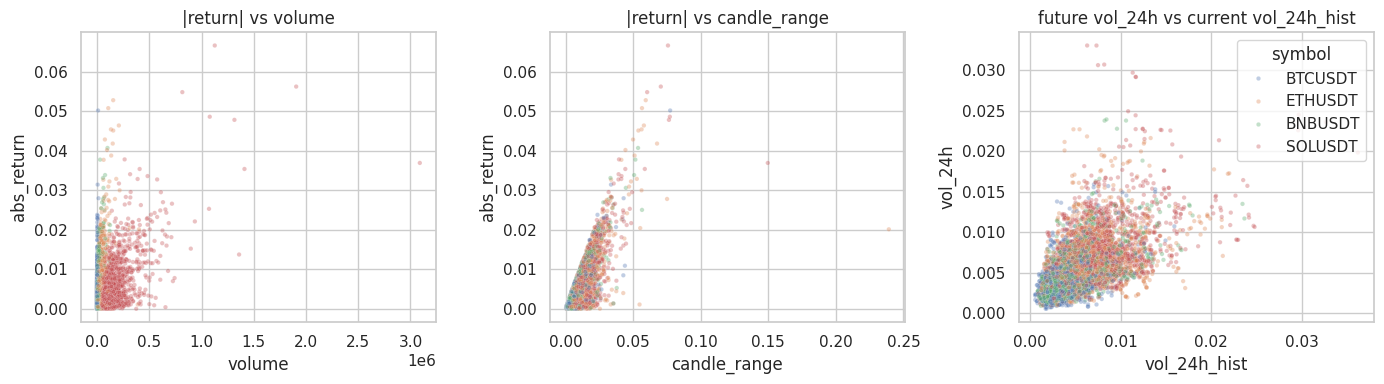

In [16]:
plot_df = df.dropna(subset=["log_return", "vol_24h"]).sample(
    n=min(8000, int(df["vol_24h"].notna().sum())), random_state=42
)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.scatterplot(data=plot_df, x="volume", y="abs_return", hue="symbol", s=10, alpha=0.35, ax=axes[0], legend=False)
axes[0].set_title("|return| vs volume")
sns.scatterplot(data=plot_df, x="candle_range", y="abs_return", hue="symbol", s=10, alpha=0.35, ax=axes[1], legend=False)
axes[1].set_title("|return| vs candle_range")
sns.scatterplot(data=plot_df, x="vol_24h_hist", y="vol_24h", hue="symbol", s=10, alpha=0.35, ax=axes[2])
axes[2].set_title("future vol_24h vs current vol_24h_hist")
plt.tight_layout()
plt.show()


## 9. Multivariate analysis


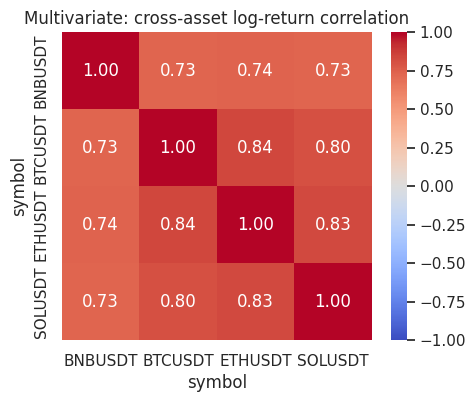

symbol,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT
symbol,,,,
BNBUSDT,1.000000,0.731849,0.741616,0.727306
BTCUSDT,0.731849,1.000000,0.839917,0.804891
ETHUSDT,0.741616,0.839917,1.000000,0.831052
SOLUSDT,0.727306,0.804891,0.831052,1.000000


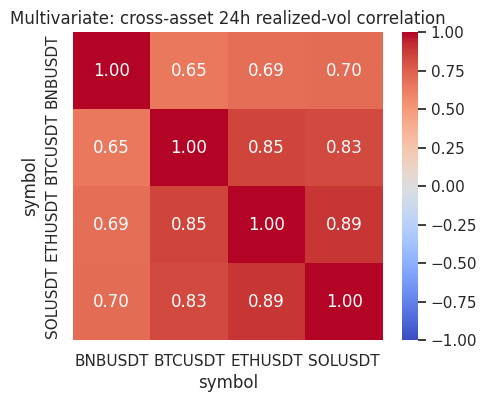

symbol,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT
symbol,,,,
BNBUSDT,1.000000,0.649044,0.692621,0.701781
BTCUSDT,0.649044,1.000000,0.847679,0.831512
ETHUSDT,0.692621,0.847679,1.000000,0.892129
SOLUSDT,0.701781,0.831512,0.892129,1.000000


In [17]:
# Cross-asset return correlation (same timestamp)
ret_wide = df.pivot_table(index="open_time", columns="symbol", values="log_return")
ret_corr = ret_wide.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(ret_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Multivariate: cross-asset log-return correlation")
plt.show()
display(ret_corr)

vol_wide = df.pivot_table(index="open_time", columns="symbol", values="vol_24h_hist")
vol_corr = vol_wide.corr()
plt.figure(figsize=(5, 4))
sns.heatmap(vol_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Multivariate: cross-asset 24h realized-vol correlation")
plt.show()
display(vol_corr)


Autocorrelation (vol clustering if vol_ac1 >> ret_ac1):


,symbol,ret_ac1,ret_ac24,vol_ac1,vol_ac24
0,BNBUSDT,0.001071,0.001900,0.990232,0.593029
1,BTCUSDT,-0.005517,0.001794,0.987882,0.499011
2,ETHUSDT,0.017219,-0.003196,0.983808,0.438655
3,SOLUSDT,0.008093,-0.006881,0.986342,0.507511


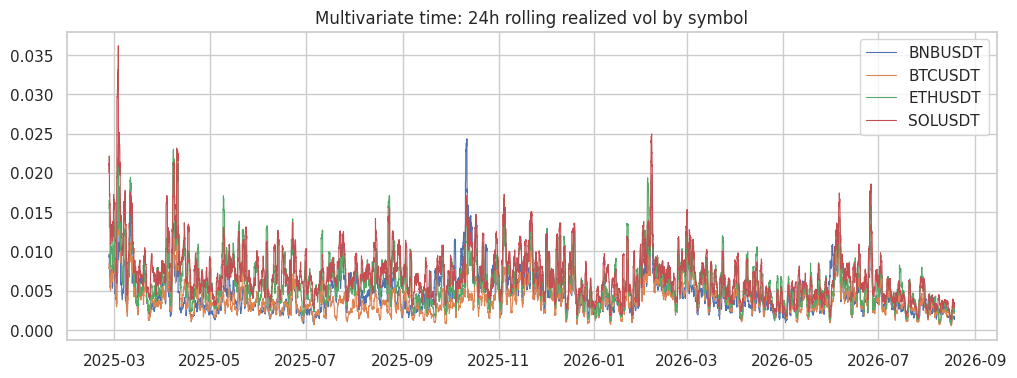

In [18]:
# Volatility clustering: autocorrelation of returns vs of rolling vol
ac_rows = []
for symbol, g in df.groupby("symbol"):
    ret = g["log_return"].dropna()
    vol = g["vol_24h_hist"].dropna()
    ac_rows.append({
        "symbol": symbol,
        "ret_ac1": float(ret.autocorr(1) or 0),
        "ret_ac24": float(ret.autocorr(24) or 0),
        "vol_ac1": float(vol.autocorr(1) or 0),
        "vol_ac24": float(vol.autocorr(24) or 0),
    })
ac_tbl = pd.DataFrame(ac_rows)
print("Autocorrelation (vol clustering if vol_ac1 >> ret_ac1):")
display(ac_tbl)

fig, ax = plt.subplots(figsize=(12, 4))
for symbol, g in df.groupby("symbol"):
    ax.plot(g["open_time"], g["vol_24h_hist"], lw=0.8, label=symbol)
ax.set_title("Multivariate time: 24h rolling realized vol by symbol")
ax.legend()
plt.show()


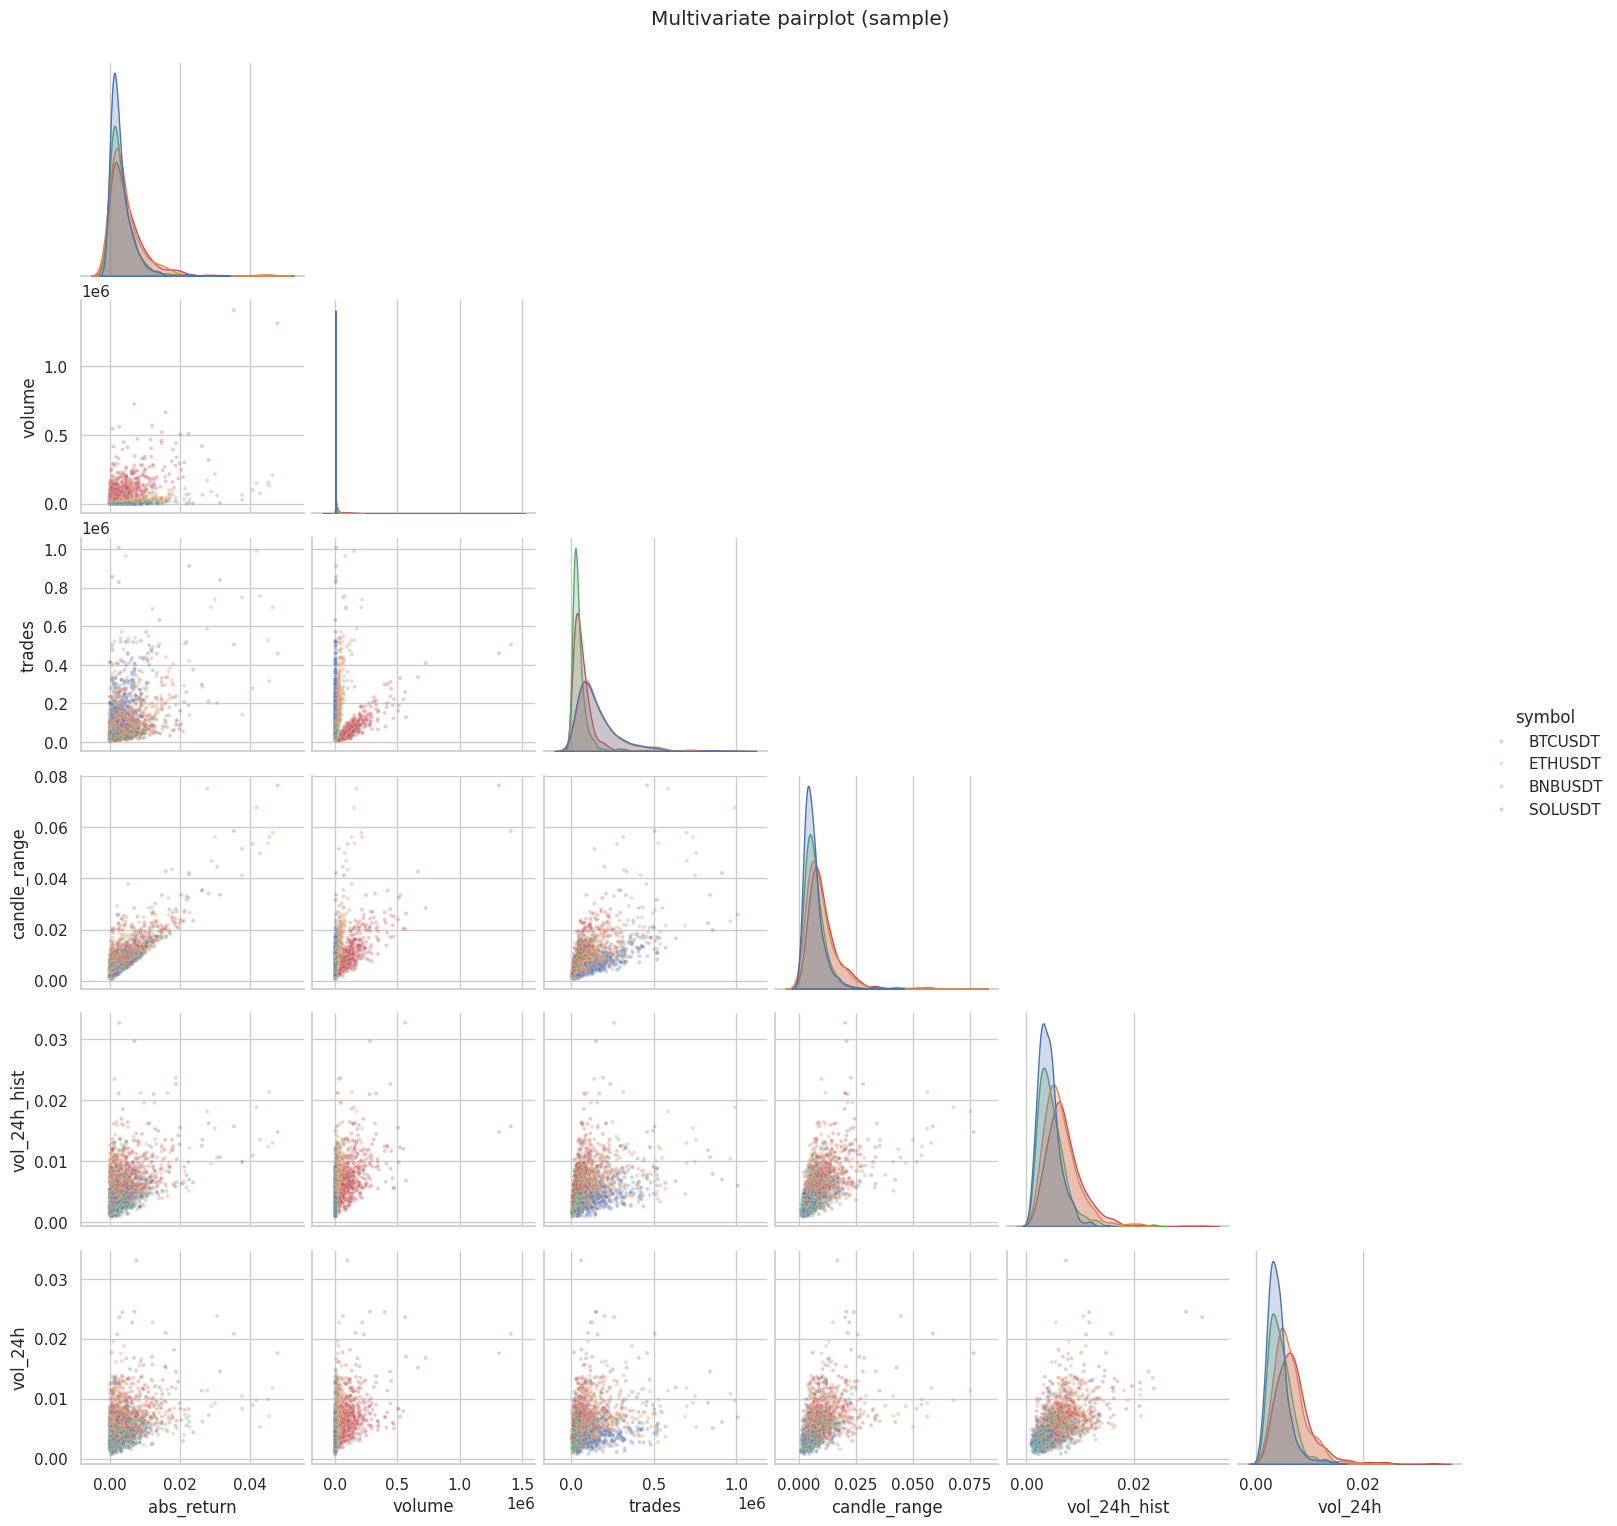

In [19]:
sample = (
    df.dropna(subset=["log_return", "vol_24h"])
      [["symbol", "abs_return", "volume", "trades", "candle_range", "vol_24h_hist", "vol_24h"]]
      .sample(n=min(2000, df["vol_24h"].notna().sum()), random_state=42)
)
sns.pairplot(sample, hue="symbol", corner=True, plot_kws={"s": 8, "alpha": 0.3})
plt.suptitle("Multivariate pairplot (sample)", y=1.02)
plt.show()


## 10. Seasonality (hour of day, day of week)


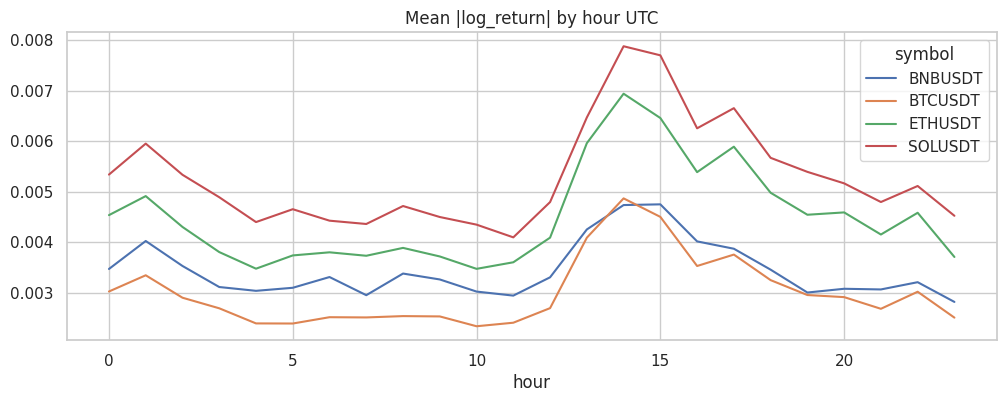

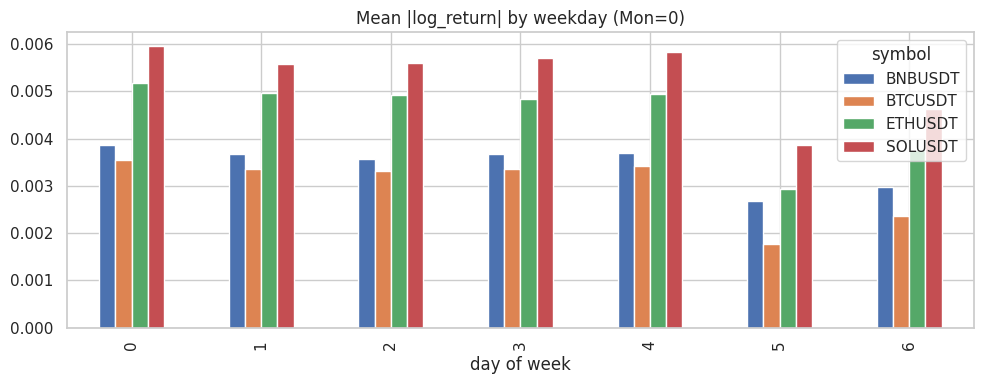

In [20]:
hour_vol = df.groupby(["symbol", "hour"])["abs_return"].mean().unstack(0)
fig, ax = plt.subplots(figsize=(12, 4))
hour_vol.plot(ax=ax)
ax.set_title("Mean |log_return| by hour UTC")
ax.set_xlabel("hour")
plt.show()

dow_vol = df.groupby(["symbol", "dow"])["abs_return"].mean().unstack(0)
fig, ax = plt.subplots(figsize=(10, 4))
dow_vol.plot(kind="bar", ax=ax)
ax.set_title("Mean |log_return| by weekday (Mon=0)")
ax.set_xlabel("day of week")
plt.tight_layout()
plt.show()


## 11. Target analysis (next-24h realized volatility)


Target vol_24h describe:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
BNBUSDT,12936.0,0.004582,0.002507,0.000852,0.002793,0.004036,0.005704,0.024348
BTCUSDT,12936.0,0.004115,0.002172,0.000540,0.002638,0.003694,0.004975,0.017119
ETHUSDT,12936.0,0.006269,0.003114,0.000705,0.004159,0.005719,0.007744,0.023637
SOLUSDT,12936.0,0.007129,0.003400,0.001361,0.004907,0.006519,0.008524,0.036169


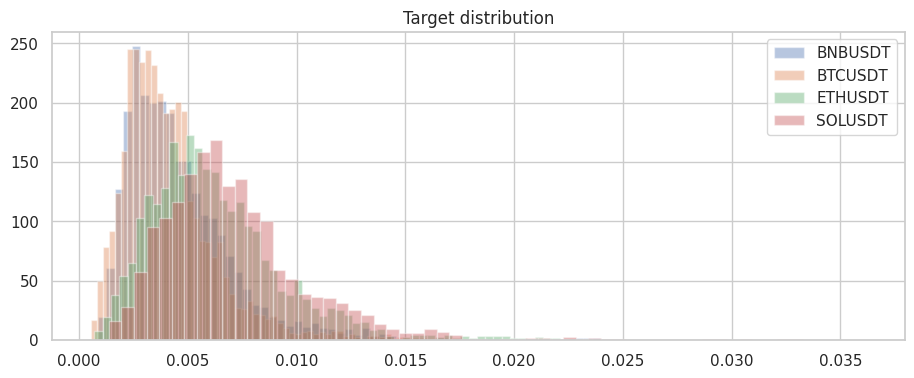

Persistence: corr(current rolling vol, future 24h vol) is the naive baseline.


In [21]:
print("Target vol_24h describe:")
display(df.groupby("symbol")["vol_24h"].describe())

plt.figure(figsize=(11, 4))
for symbol, g in df.groupby("symbol"):
    plt.hist(g["vol_24h"].dropna(), bins=60, alpha=0.4, density=True, label=symbol)
plt.title("Target distribution")
plt.legend()
plt.show()

print("Persistence: corr(current rolling vol, future 24h vol) is the naive baseline.")


## 12. EDA conclusions (use these for feature engineering next)

This cell only **prints recommendations**. It does not write the production feature table.


In [22]:
print(
'''Recommended for feature engineering (from this EDA):
1. Do NOT use raw close/open/high/low as model features (non-stationary, dominated by level).
2. Use returns, rolling realized vol (6/24/72h) — vol clustering is very strong (vol_ac1 ~ 0.98).
3. Fat tails / outliers: keep them; add candle_range and Bollinger width, do not winsorize aggressively.
4. Volume and trades: use z-scores or log, not raw volume (scale differs by symbol).
5. Add hour-of-day (seasonality exists). Day-of-week optional.
6. Add symbol_id (different vol scales across BTC/ETH/BNB/SOL).
7. OHLC consistency is generally clean; drop or forward-fill any hourly gaps if missing_hours > 0.
8. Target is regression vol_24h; last 24 rows per symbol have no label.
9. Strongest naive feature is vol_24h_hist (persistence). Trees should beat it on RMSE/MAE.
10. No PII / no class imbalance problem (not classification).
'''
)


Recommended for feature engineering (from this EDA):
1. Do NOT use raw close/open/high/low as model features (non-stationary, dominated by level).
2. Use returns, rolling realized vol (6/24/72h) — vol clustering is very strong (vol_ac1 ~ 0.98).
3. Fat tails / outliers: keep them; add candle_range and Bollinger width, do not winsorize aggressively.
4. Volume and trades: use z-scores or log, not raw volume (scale differs by symbol).
5. Add hour-of-day (seasonality exists). Day-of-week optional.
6. Add symbol_id (different vol scales across BTC/ETH/BNB/SOL).
7. OHLC consistency is generally clean; drop or forward-fill any hourly gaps if missing_hours > 0.
8. Target is regression vol_24h; last 24 rows per symbol have no label.
9. Strongest naive feature is vol_24h_hist (persistence). Trees should beat it on RMSE/MAE.
10. No PII / no class imbalance problem (not classification).



## 13. Save findings (send this back with the executed notebook)


In [24]:
findings = {
    "source": SOURCE,
    "shape": list(df.shape),
    "columns": list(df.columns),
    "symbols": sorted(df["symbol"].dropna().unique().tolist()),
    "time_min": str(df["open_time"].min()),
    "time_max": str(df["open_time"].max()),
    "issues": issues,
    "hourly_gaps": gap_tbl.to_dict(orient="records"),
    "return_kurtosis": df.groupby("symbol")["log_return"].agg(pd.Series.kurtosis).to_dict(),
    "return_skew": df.groupby("symbol")["log_return"].skew().to_dict(),
    "autocorr": ac_tbl.to_dict(orient="records"),
    "corr_with_target": corr["vol_24h"].dropna().to_dict() if "vol_24h" in corr.columns else {},
    "cross_asset_return_corr": ret_corr.to_dict(),
    "iqr_outlier_share": outlier_df.to_dict(orient="records"),
}

out_path = Path("eda_findings.json")
out_path.write_text(json.dumps(findings, indent=2, default=str), encoding="utf-8")
print("Wrote", out_path.resolve())

if IN_COLAB:
    from google.colab import files
    files.download(str(out_path))
    print("Download this notebook: File → Download → Download .ipynb")

Wrote /content/eda_findings.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download this notebook: File → Download → Download .ipynb
